In [362]:
## Scaler assignment due 21st May on text classification

In [364]:
import numpy as np
import pandas as pd

In [365]:
import matplotlib.pyplot as plt

In [366]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [367]:
import gensim

In [368]:
data=pd.read_csv('flipitnews-data.csv')

In [369]:
data.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


In [370]:
data.shape

(2225, 2)

In [371]:
data['Category'].value_counts()

Category
Sports           511
Business         510
Politics         417
Technology       401
Entertainment    386
Name: count, dtype: int64

In [372]:
import nltk

In [373]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [374]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [375]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [376]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [377]:
from nltk.tokenize import word_tokenize

In [378]:
data['word tokens']=data['Article'].apply(word_tokenize)

In [379]:
data.shape

(2225, 3)

In [380]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [381]:
lemma=WordNetLemmatizer()

In [382]:
lemmatizer=lambda x: [lemma.lemmatize(i) for i in x]

In [383]:
data['lemmatized']=data['word tokens'].apply(lemmatizer)

In [384]:
data

,Category,Article,word tokens,lemmatized
0,Technology,tv future in the hands of viewers with home th...,"[tv, future, in, the, hands, of, viewers, with...","[tv, future, in, the, hand, of, viewer, with, ..."
1,Business,worldcom boss left books alone former worldc...,"[worldcom, boss, left, books, alone, former, w...","[worldcom, bos, left, book, alone, former, wor..."
2,Sports,tigers wary of farrell gamble leicester say ...,"[tigers, wary, of, farrell, gamble, leicester,...","[tiger, wary, of, farrell, gamble, leicester, ..."
3,Sports,yeading face newcastle in fa cup premiership s...,"[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, in, fa, cup, premie..."
4,Entertainment,ocean s twelve raids box office ocean s twelve...,"[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, s, twelve, raid, box, office, ocean, s..."
...,...,...,...,...
2220,Business,cars pull down us retail figures us retail sal...,"[cars, pull, down, us, retail, figures, us, re...","[car, pull, down, u, retail, figure, u, retail..."
2221,Politics,kilroy unveils immigration policy ex-chatshow ...,"[kilroy, unveils, immigration, policy, ex-chat...","[kilroy, unveils, immigration, policy, ex-chat..."
2222,Entertainment,rem announce new glasgow concert us band rem h...,"[rem, announce, new, glasgow, concert, us, ban...","[rem, announce, new, glasgow, concert, u, band..."
2223,Politics,how political squabbles snowball it s become c...,"[how, political, squabbles, snowball, it, s, b...","[how, political, squabble, snowball, it, s, be..."


In [385]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [386]:
from nltk.corpus import stopwords

In [387]:
from gensim.parsing.preprocessing import STOPWORDS, remove_stopwords

In [388]:
print(STOPWORDS)

frozenset({'front', 'quite', 'own', 'however', 'towards', 'say', 'cry', 'nothing', 'or', 'whole', 'at', 'done', 'why', 'your', 'elsewhere', 'the', 'still', 'both', 'only', 'almost', 'who', 'them', 'fill', 'there', 'sixty', 'where', 'our', 'yourself', 'side', 'here', 'more', 'regarding', 'none', 'last', 'yours', 'itself', 'really', 'by', 'had', 'ltd', 'detail', 'whither', 'next', 'call', 'all', 'mill', 'which', 'either', 'from', 'whenever', 'around', 'afterwards', 'their', 'her', 'that', 'myself', 'move', 'these', 'bottom', 'ever', 'due', 'somehow', 'with', 'wherever', 'being', 'please', 'under', 'my', 'often', 'three', 'his', 'over', 'much', 'an', 're', 'would', 'didn', 'during', 'thick', 'de', 'computer', 'moreover', 'via', 'someone', 'cant', 'ours', 'fifteen', 'across', 'whom', 'sometimes', 'make', 'every', 'seem', 'in', 'nine', 'eg', 'might', 'too', 'whose', 'therefore', 'after', 'five', 'hereby', 'yet', 'un', 'everything', 'upon', 'see', 'keep', 'get', 'else', 'now', 'km', 'otherwi

In [389]:
print(stopwords.words('English'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [390]:
data['cleaned']=data['lemmatized'].apply(lambda x: ' '.join(x))

In [391]:
data

,Category,Article,word tokens,lemmatized,cleaned
0,Technology,tv future in the hands of viewers with home th...,"[tv, future, in, the, hands, of, viewers, with...","[tv, future, in, the, hand, of, viewer, with, ...",tv future in the hand of viewer with home thea...
1,Business,worldcom boss left books alone former worldc...,"[worldcom, boss, left, books, alone, former, w...","[worldcom, bos, left, book, alone, former, wor...",worldcom bos left book alone former worldcom b...
2,Sports,tigers wary of farrell gamble leicester say ...,"[tigers, wary, of, farrell, gamble, leicester,...","[tiger, wary, of, farrell, gamble, leicester, ...",tiger wary of farrell gamble leicester say the...
3,Sports,yeading face newcastle in fa cup premiership s...,"[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, in, fa, cup, premie...",yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...,"[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, s, twelve, raid, box, office, ocean, s...",ocean s twelve raid box office ocean s twelve ...
...,...,...,...,...,...
2220,Business,cars pull down us retail figures us retail sal...,"[cars, pull, down, us, retail, figures, us, re...","[car, pull, down, u, retail, figure, u, retail...",car pull down u retail figure u retail sale fe...
2221,Politics,kilroy unveils immigration policy ex-chatshow ...,"[kilroy, unveils, immigration, policy, ex-chat...","[kilroy, unveils, immigration, policy, ex-chat...",kilroy unveils immigration policy ex-chatshow ...
2222,Entertainment,rem announce new glasgow concert us band rem h...,"[rem, announce, new, glasgow, concert, us, ban...","[rem, announce, new, glasgow, concert, u, band...",rem announce new glasgow concert u band rem ha...
2223,Politics,how political squabbles snowball it s become c...,"[how, political, squabbles, snowball, it, s, b...","[how, political, squabble, snowball, it, s, be...",how political squabble snowball it s become co...


In [392]:
data['remove_stop']=data['cleaned'].apply(remove_stopwords) #this is what I will use for classification

In [393]:
tech_articles=data[data['Category']=='Technology']

In [394]:
sports_articles=data[data['Category']=='Sports']

In [395]:
sports_words=" ".join(sports_articles['remove_stop'])

In [396]:
tech_words=" ".join(tech_articles['remove_stop'])

In [397]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [398]:
from wordcloud import WordCloud

In [399]:
wordcloud_tech=WordCloud(random_state=10).generate(tech_words)

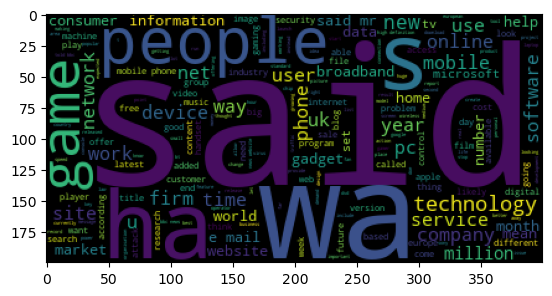

In [400]:
plt.imshow(wordcloud_tech)

In [401]:
word_cloud_sport=WordCloud(random_state=10).generate(sports_words)

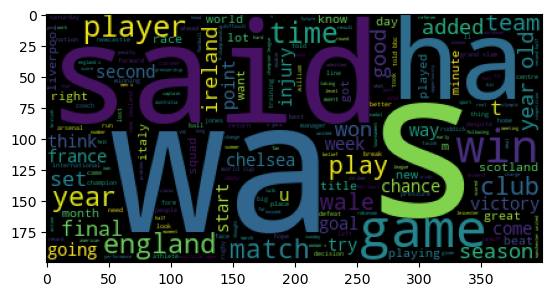

In [402]:
plt.imshow(word_cloud_sport)

In [403]:
#Based on these word clouds, I see that some more words need to be removed

In [404]:
data['remove_stop']=data['remove_stop'].apply(lambda x:' '.join([i for i in x.split() if i not in ['ha','wa','s','S','said','mr','u']]))

In [405]:
tech_articles=data[data['Category']=='Technology']

In [406]:
sports_articles=data[data['Category']=='Sports']

In [407]:
business_articles=data[data['Category']=='Business']

In [408]:
sports_articles=data[data['Category']=='Sports']

In [409]:
ent_articles=data[data['Category']=='Entertainment']

In [410]:
pol_articles=data[data['Category']=='Politics']

In [411]:
sports_words=" ".join(sports_articles['remove_stop'])

In [412]:
tech_words=" ".join(tech_articles['remove_stop'])

In [413]:
ent_words=' '.join(ent_articles['remove_stop'])

In [414]:
bus_words=' '.join(business_articles['remove_stop'])

In [415]:
pol_words=' '.join(pol_articles['remove_stop'])

In [416]:
wordcloud_tech=WordCloud(random_state=10).generate(tech_words)

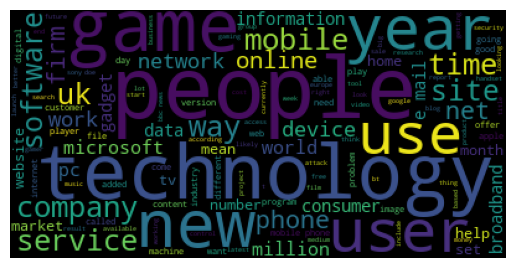

In [417]:
plt.imshow(wordcloud_tech)
plt.axis('off')
plt.show()

In [418]:
word_cloud_sport=WordCloud(random_state=10).generate(sports_words)

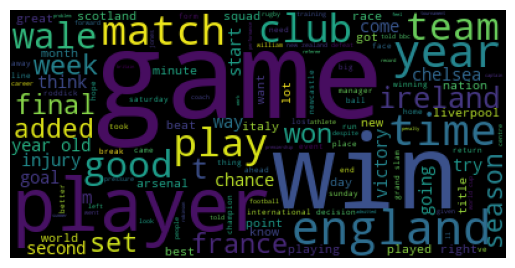

In [419]:
plt.imshow(word_cloud_sport)
plt.axis('off')
plt.show()

In [420]:
word_cloud_bus=WordCloud(random_state=10).generate(bus_words)

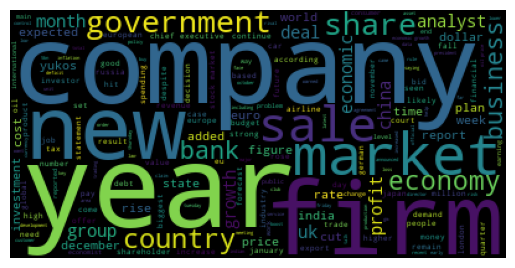

In [421]:
plt.imshow(word_cloud_bus)
plt.axis('off')
plt.show()

In [422]:
word_cloud_ent=WordCloud(random_state=10).generate(ent_words)

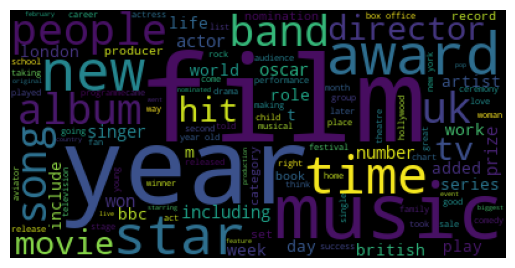

In [423]:
plt.imshow(word_cloud_ent)
plt.axis('off')
plt.show()

In [424]:
word_cloud_pol=WordCloud(random_state=10).generate(pol_words)

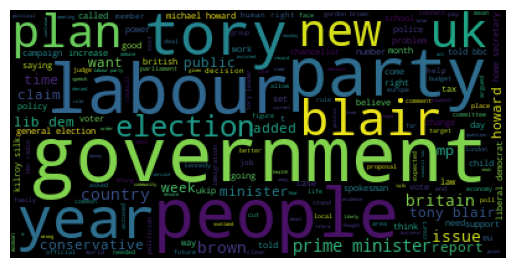

In [425]:
plt.imshow(word_cloud_pol)
plt.axis('off')
plt.show()

In [426]:
#Now the wordclouds show that the data is reasonably clean, I will use this for classification

In [427]:
data_new=data[['Category','remove_stop']]

In [428]:
data_new

,Category,remove_stop
0,Technology,tv future hand viewer home theatre plasma high...
1,Business,worldcom bos left book worldcom bos bernie ebb...
2,Sports,tiger wary farrell gamble leicester rushed mak...
3,Sports,yeading face newcastle fa cup premiership newc...
4,Entertainment,ocean raid box office ocean crime caper sequel...
...,...,...
2220,Business,car pull retail figure retail sale fell 0.3 % ...
2221,Politics,kilroy unveils immigration policy ex-chatshow ...
2222,Entertainment,rem announce new glasgow concert band rem anno...
2223,Politics,political squabble snowball commonplace argue ...


In [429]:
data_new

,Category,remove_stop
0,Technology,tv future hand viewer home theatre plasma high...
1,Business,worldcom bos left book worldcom bos bernie ebb...
2,Sports,tiger wary farrell gamble leicester rushed mak...
3,Sports,yeading face newcastle fa cup premiership newc...
4,Entertainment,ocean raid box office ocean crime caper sequel...
...,...,...
2220,Business,car pull retail figure retail sale fell 0.3 % ...
2221,Politics,kilroy unveils immigration policy ex-chatshow ...
2222,Entertainment,rem announce new glasgow concert band rem anno...
2223,Politics,political squabble snowball commonplace argue ...


In [430]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [431]:
countvec=CountVectorizer()

In [432]:
tfidf=TfidfVectorizer()

In [433]:
from sklearn.model_selection import train_test_split

In [434]:
x=data_new['remove_stop']

In [435]:
y=data_new['Category']

In [436]:
enc=LabelEncoder()

In [437]:
y_enc=enc.fit_transform(y)

In [438]:
y_enc

array([4, 0, 3, ..., 1, 2, 3], shape=(2225,))

In [439]:
xtrain, xtest, ytrain, ytest=train_test_split(x, y_enc, test_size=0.25, random_state=10)

In [440]:
xtrain_enc_cv=countvec.fit_transform(xtrain)

In [441]:
xtest_enc_cv=countvec.transform(xtest)

In [442]:
xtrain_enc.shape

(1780, 24088)

In [443]:
xtest_enc.shape

(445, 24088)

In [444]:
from sklearn.naive_bayes import MultinomialNB

In [445]:
model_nb_1=MultinomialNB()

In [446]:
model_nb_1.fit(xtrain_enc_cv, ytrain)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [447]:
ypred_cv=model_nb_1.predict(xtest_enc_cv)

In [448]:
from sklearn.metrics import classification_report

In [449]:
print(classification_report(ytest, ypred_cv))

              precision    recall  f1-score   support

           0       0.98      0.93      0.96       126
           1       1.00      0.94      0.97        96
           2       0.92      0.98      0.95       112
           3       1.00      0.99      1.00       118
           4       0.94      1.00      0.97       105

    accuracy                           0.97       557
   macro avg       0.97      0.97      0.97       557
weighted avg       0.97      0.97      0.97       557



In [450]:
#Even with a simple bag of words I am getting 93-100% recall and precision across most classes

In [451]:
xtrain_enc=tfidf.fit_transform(xtrain)

In [452]:
xtest_enc=tfidf.transform(xtest)

In [453]:
ytrain

array([4, 0, 3, ..., 4, 0, 4], shape=(1668,))

In [454]:
model=MultinomialNB()

In [455]:
model.fit(xtrain_enc, ytrain)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [456]:
ypred=model.predict(xtest_enc)

In [457]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       126
           1       1.00      0.91      0.95        96
           2       0.96      0.96      0.96       112
           3       0.97      0.99      0.98       118
           4       0.96      0.99      0.98       105

    accuracy                           0.97       557
   macro avg       0.97      0.96      0.97       557
weighted avg       0.97      0.97      0.97       557



In [458]:
from sklearn.ensemble import RandomForestClassifier

In [459]:
model_rf=RandomForestClassifier()

In [460]:
model_rf.fit(xtrain_enc, ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [461]:
ypred_rf=model_rf.predict(xtest_enc)

In [462]:
print(classification_report(ytest, ypred_rf))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       126
           1       0.99      0.97      0.98        96
           2       0.97      0.93      0.95       112
           3       0.95      0.98      0.97       118
           4       0.98      0.92      0.95       105

    accuracy                           0.95       557
   macro avg       0.96      0.95      0.95       557
weighted avg       0.95      0.95      0.95       557



In [463]:
#Overall accuracy is marginally better with Naive bayes classifier

In [464]:
from sklearn.neighbors import KNeighborsClassifier

In [465]:
model_knn=KNeighborsClassifier()

In [466]:
model_knn.fit(xtrain_enc, ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [467]:
ypred_knn=model_knn.predict(xtest_enc)

In [468]:
print(classification_report(ytest, ypred_knn))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92       126
           1       0.97      0.90      0.93        96
           2       0.85      0.93      0.89       112
           3       0.98      0.97      0.97       118
           4       0.89      0.96      0.92       105

    accuracy                           0.93       557
   macro avg       0.93      0.93      0.93       557
weighted avg       0.93      0.93      0.93       557



In [469]:
#clearly using simple distance even without any training itself, we are getting nearly 91% accuracy.
#This has improved with training using the NB models

In [470]:
#Now trying to use ngrams in tfidf vectorizer

In [471]:
tfidf_2=TfidfVectorizer(ngram_range=(1,3))

In [472]:
xtrain_enc_2=tfidf_2.fit_transform(xtrain)

In [473]:
xtest_enc_2=tfidf_2.transform(xtest)

In [474]:
model_nb_new=MultinomialNB()

In [475]:
model_nb_new.fit(xtrain_enc_2, ytrain)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [476]:
ypred_new_tf=model_nb_new.predict(xtest_enc_2)

In [477]:
print(classification_report(ytest, ypred_new_tf))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       126
           1       1.00      0.88      0.93        96
           2       0.98      0.93      0.95       112
           3       0.94      0.99      0.96       118
           4       0.98      0.97      0.98       105

    accuracy                           0.96       557
   macro avg       0.96      0.95      0.95       557
weighted avg       0.96      0.96      0.95       557



In [478]:
#In this case using ngrams has actually reduced the overall accuracy slightly

In [479]:
#Conclusions
#1. The Multinomial Naive Bayes performs very well with text classification
#2. Even without training, using a simple KNN search, the tfidf embeddings give good accuracy, which means different categories or topics have different word frequencies
#3. Using random forest or using n grams does not do so well here, I would say order of words does not matter
